# PCA + Linear Regression: Auto MPG

## Problem Statement
Test whether PCA-based dimensionality reduction retains enough signal to predict mpg with a linear model, compared to using all original features.

## Dataset
Same Auto MPG dataset as the regression notebook (mpg, cylinders, displacement, horsepower, weight, acceleration).

## Approach
Cleaned the horsepower column (same '?' -> numeric fix as the regression notebook), z-score standardized the features, ran PCA (6 and 3 components) to inspect explained variance, then compared a Linear Regression fit on the raw scaled features vs. on the 3-component PCA projection.

## Conclusion
Shows the R^2 tradeoff between using all original (scaled) features vs. a compressed 3-component PCA representation.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [4]:
data=pd.read_csv("auto-mpg.csv")

In [5]:
data.shape

(398, 9)

In [6]:
data.isnull().values.any()

False

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [9]:
data.head(50)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [10]:
data=data.drop(['car name','origin'],axis=1)

In [13]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


In [14]:
hp_digit=pd.DataFrame(data.horsepower.str.isdigit())

In [15]:
data[hp_digit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,?,2046,19.0,71
126,21.0,6,200.0,?,2875,17.0,74
330,40.9,4,85.0,?,1835,17.3,80
336,23.6,4,140.0,?,2905,14.3,80
354,34.5,4,100.0,?,2320,15.8,81
374,23.0,4,151.0,?,3035,20.5,82


In [16]:
data=data.replace('?',np.nan)

In [ ]:
# Fixed: convert horsepower to numeric BEFORE computing medians -- 
# it was still 'object' dtype (mixed strings + NaN) at this point, which
# made x.median() fail with "Cannot perform reduction 'median' with string dtype".
data['horsepower'] = data['horsepower'].astype('float64')

In [17]:
data[hp_digit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,NaN,2046,19.0,71
126,21.0,6,200.0,NaN,2875,17.0,74
330,40.9,4,85.0,NaN,1835,17.3,80
336,23.6,4,140.0,NaN,2905,14.3,80
354,34.5,4,100.0,NaN,2320,15.8,81
374,23.0,4,151.0,NaN,3035,20.5,82


In [19]:
#median imputation
m=lambda x:x.fillna(x.median())
data=data.apply(m,axis=0)

In [21]:
x=data.drop('mpg',axis=1)
y=data['mpg']

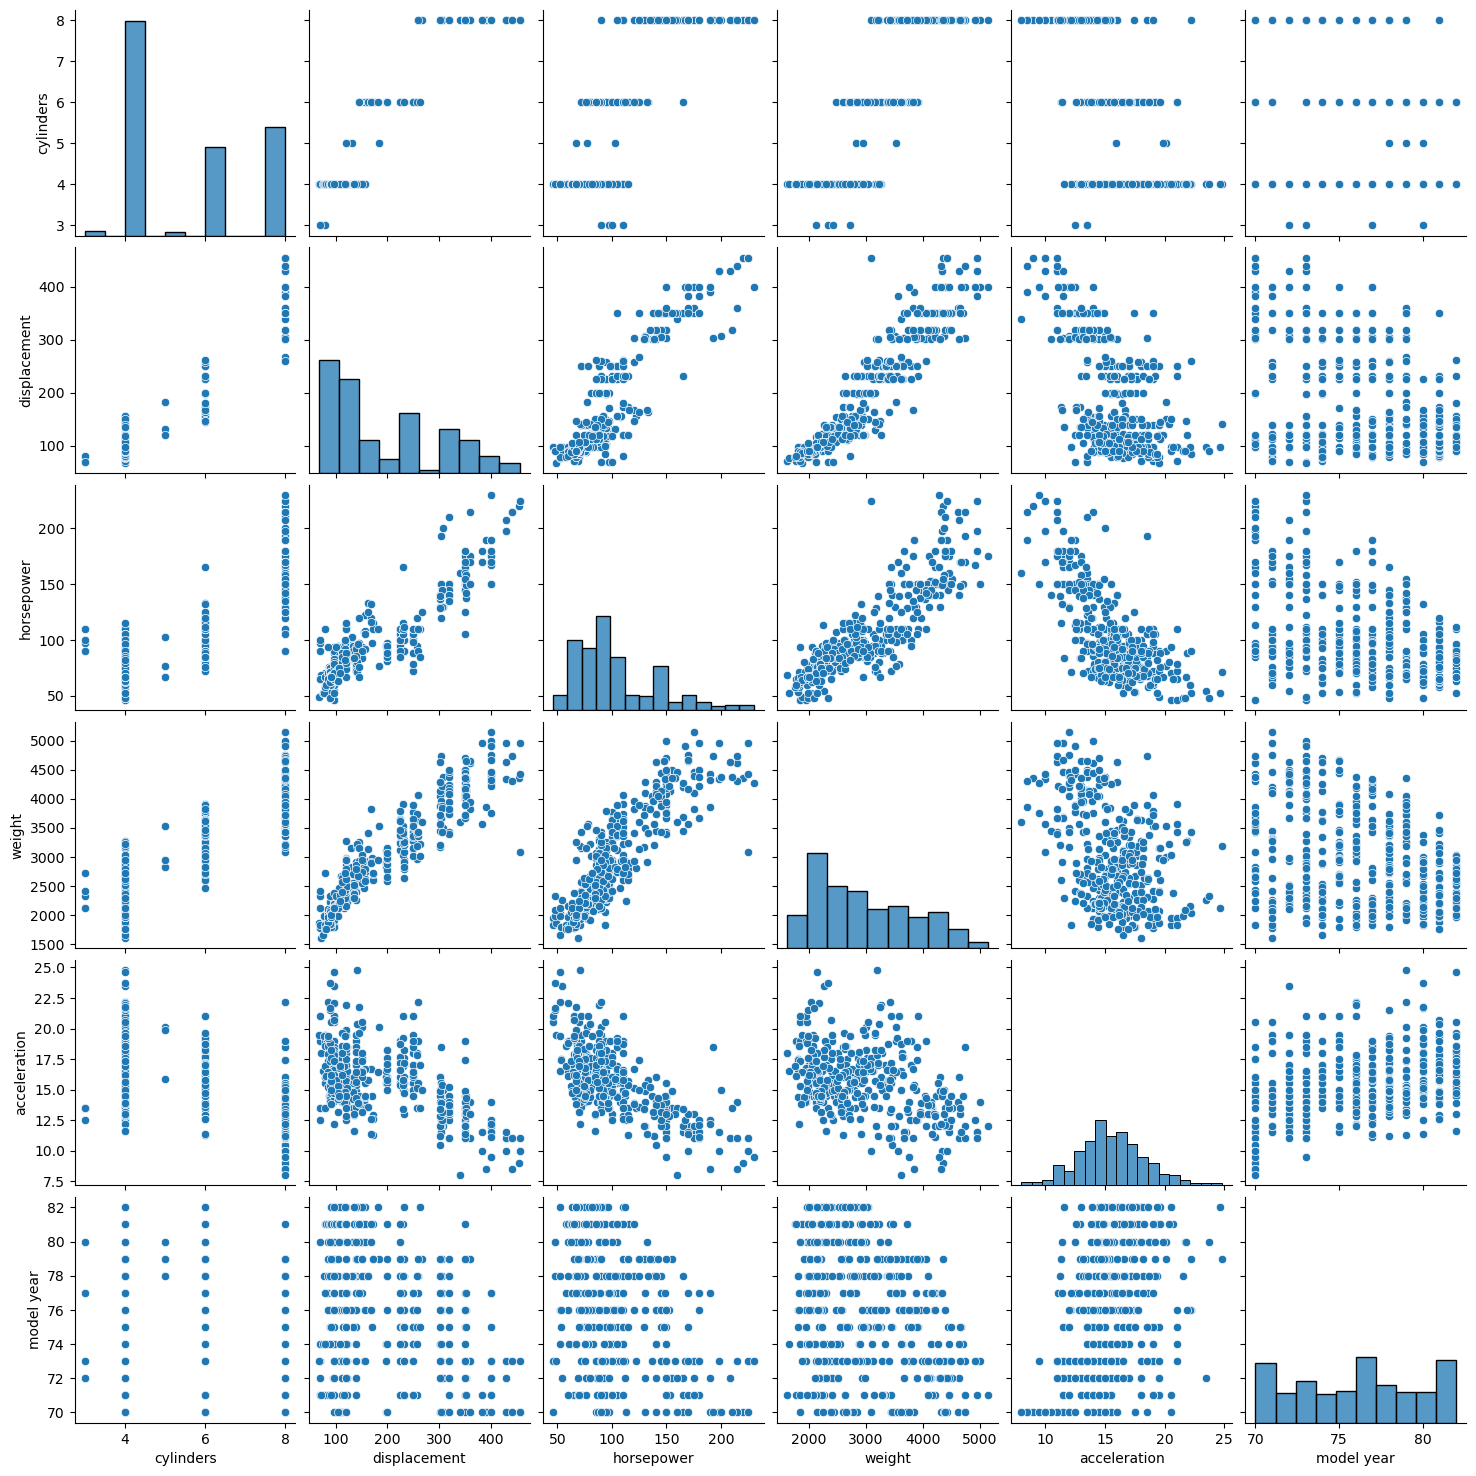

In [22]:
sns.pairplot(x)

In [23]:
from scipy.stats import zscore

In [24]:
x_scaled=x.apply(zscore)

In [25]:
#cov
cov_matrix=np.cov(x_scaled)

In [26]:
print(cov_matrix)

[[ 1.69102784  1.93540823  1.86251231 ... -0.62298943 -1.36721314
  -1.43506643]
 [ 1.93540823  2.33586906  2.21276619 ... -0.63288102 -1.60932872
  -1.69066137]
 [ 1.86251231  2.21276619  2.11762849 ... -0.55719372 -1.52549193
  -1.61113791]
 ...
 [-0.62298943 -0.63288102 -0.55719372 ...  1.11546674  0.57819338
   0.50963654]
 [-1.36721314 -1.60932872 -1.52549193 ...  0.57819338  1.13557484
   1.17986804]
 [-1.43506643 -1.69066137 -1.61113791 ...  0.50963654  1.17986804
   1.23739299]]


In [28]:
pca=PCA(n_components=6)

In [29]:
pca.fit(x_scaled)

PCA(n_components=6)

In [33]:
print(pca.explained_variance_) #Eigen values

[4.26378678 0.84068225 0.67499578 0.13552589 0.06386533 0.03625731]


In [34]:
print(pca.components_) #Eigen Vectors

[[ 0.45509041  0.46913807  0.46318283  0.44618821 -0.32466834 -0.23188446]
 [ 0.18276349  0.16077095  0.0139189   0.25676595  0.21039209  0.9112425 ]
 [ 0.17104591  0.13443134 -0.12440857  0.27156481  0.86752316 -0.33294164]
 [-0.65709523 -0.18742114  0.62819714  0.33868744  0.15214558  0.02469974]
 [ 0.28804531 -0.00141408  0.60418441 -0.68887559  0.27061128  0.06487726]
 [-0.46420823  0.83717483 -0.10059817 -0.26829299  0.0367486   0.01405118]]


Variance Explained


<function matplotlib.pyplot.show(close=None, block=None)>

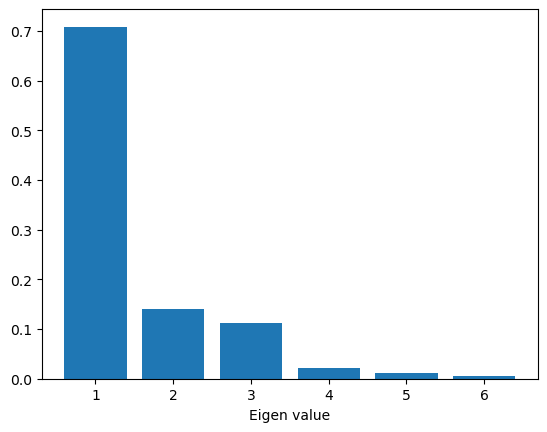

In [37]:
plt.bar(list(range(1,7)),pca.explained_variance_ratio_)
print("Variance Explained")
plt.xlabel("Eigen value")
plt.show

In [39]:
pca3=PCA(n_components=3)
pca3.fit(x_scaled)

PCA(n_components=3)

In [40]:
print(pca.explained_variance_) #Eigen values

[4.26378678 0.84068225 0.67499578 0.13552589 0.06386533 0.03625731]


In [41]:
print(pca.components_) #Eigen Vectors

[[ 0.45509041  0.46913807  0.46318283  0.44618821 -0.32466834 -0.23188446]
 [ 0.18276349  0.16077095  0.0139189   0.25676595  0.21039209  0.9112425 ]
 [ 0.17104591  0.13443134 -0.12440857  0.27156481  0.86752316 -0.33294164]
 [-0.65709523 -0.18742114  0.62819714  0.33868744  0.15214558  0.02469974]
 [ 0.28804531 -0.00141408  0.60418441 -0.68887559  0.27061128  0.06487726]
 [-0.46420823  0.83717483 -0.10059817 -0.26829299  0.0367486   0.01405118]]


Variance Explained


<function matplotlib.pyplot.show(close=None, block=None)>

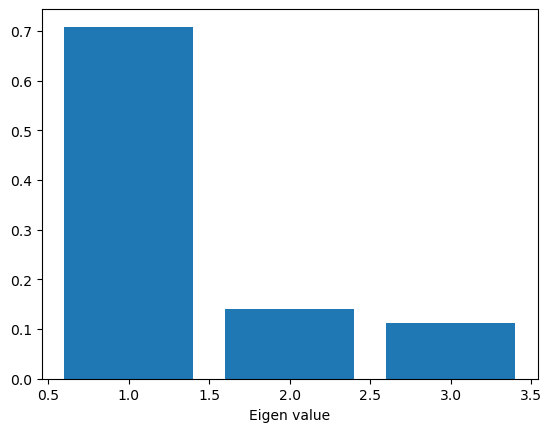

In [47]:
plt.bar(list(range(1,4)),pca3.explained_variance_ratio_)
print("Variance Explained")
plt.xlabel("Eigen value")
plt.show

In [49]:
regression_model=LinearRegression()

In [51]:
regression_model.fit(x_scaled,y)

LinearRegression()

In [52]:
print("score:",regression_model.score(x_scaled,y))

score: 0.8087079552406331


In [53]:
xpca3=pca3.transform(x_scaled)

<BarContainer object of 3 artists>

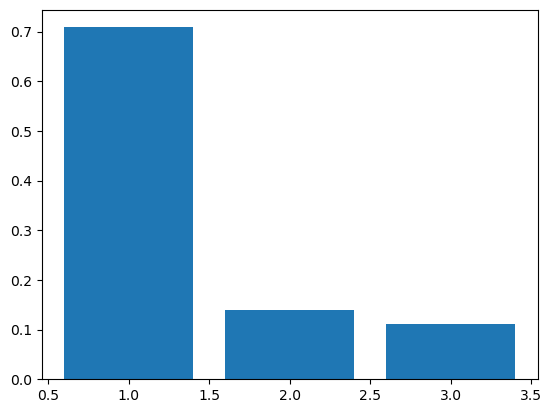

In [55]:
plt.bar(list(range(1,4)),pca3.explained_variance_ratio_)

In [56]:
reg_model_pca=LinearRegression()

In [57]:
reg_model_pca.fit(xpca3,y)

LinearRegression()

In [58]:
print("Model score after applying pca:",reg_model_pca.score(xpca3,y))

Model score after applying pca: 0.7799909620572006
